<a href="https://colab.research.google.com/github/felondrum/llm_driven_development_otus/blob/develop/hw2_student_version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📚 ДЗ №2: Работа с данными для LLM

## 🎯 Цель задания
После выполнения задания вы сможете:
- Предобрабатывать русскоязычные текстовые данные для LLM
- Работать с готовыми моделями HuggingFace для анализа тональности и NER
- Создавать эффективные промпты для LLM API
- Сравнивать качество работы разных подходов к анализу текста
- Формировать датасеты в формате instruction-following для fine-tuning
- Сохранять данные в правильных форматах для обучения LLM

## 📝 Структура задания
- **Часть 1** (35% оценки): Предобработка данных и работа с готовыми моделями
- **Часть 2** (35% оценки): LLM API и prompt engineering
- **Часть 3** (20% оценки): Подготовка данных для fine-tuning LLM
- **Часть 4** (10% оценки): Сравнительный анализ и визуализация

## ⚡ Критерии оценки
- Качество предобработки данных: 25%
- Корректность работы с готовыми моделями: 20%
- Эффективность промптов для LLM: 25%
- Правильность подготовки данных для fine-tuning: 20%
- Качество сравнительного анализа: 10%


## 🔧 Установка зависимостей

Установим необходимые библиотеки для работы с данными, готовыми моделями и LLM API.


In [1]:
%pip install pandas numpy matplotlib seaborn
%pip install transformers torch
%pip install openai>=1.0.0  # Для работы с OpenAI API
%pip install datasets
%pip install pymorphy2



  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 59.9 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=62189cc58141cc1a027b1f2426ea1a7eeb9563089c6d17b5d352aa10b253f15c
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
Successfully built docopt


In [2]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from typing import List, Dict, Tuple
from transformers import pipeline, AutoTokenizer, AutoModelForTokenClassification
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

print("Библиотеки загружены успешно!")



Библиотеки загружены успешно!


## 📊 Часть 1: Предобработка данных и готовые модели (35% оценки)

### Задание 1.1: Анализ "грязного" датасета

Проанализируем реалистичный датасет с типичными проблемами: опечатки, разные регистры, лишние пробелы, эмодзи.


In [13]:
# Создаем "грязный" датасет с типичными проблемами реальных данных
# Включаем сложные случаи для демонстрации преимуществ LLM
raw_reviews = [
    # Простые случаи
    "отличный iphone 14 PRO!!!  купил в магазине  apple на тверской 😊. Камера супер",
    "УЖАСНОЕ обслуживание в сбербанке на красной площади.. менеджер иван петров вобще не помог(",

    # Сарказм и ирония (сложно для классических моделей)
    "Спасибо огромное сотрудникам МТС за то что 3 часа держали меня в очереди! Просто восхитительно 👏",
    "Какой замечательный сервис в Пятерочке - касса сломалась прямо передо мной, а персонал даже не извинился",

    # Смешанные эмоции
    "iPhone 13 хороший телефон, но цена кусается. В целом доволен покупкой в re:Store",
    "Ресторан Белуга красивый и атмосфера приятная, но официант Максим был невнимателен",

    # Сложная структура предложений
    "Хотя Tesla Model Y и дорогая машина, и сервис в Рольф Премиум иногда подводит, но в целом я очень доволен покупкой",
    "Не могу сказать что отель Ритц-Карлтон плохой, просто ожидал большего за такие деньги",

    # Контекстно-зависимые случаи
    "Заказал доставку в Яндекс.Еде из ресторана Дача на Рублевке - привезли холодное, но курьер Андрей был вежливый",
    "MacBook Pro 16 работает как часы уже год, покупал в iStore на Арбате у консультанта Елены",

    # Неоднозначные случаи
    "Сходил в кинотеатр Октябрь посмотреть новый фильм Marvel - ну такое себе, но попкорн вкусный был",
    "Обслуживание в банке ВТБ на Тверской оставляет желать лучшего, хотя менеджер Ольга старалась помочь",

    # Сложные именованные сущности
    "Купил новый Samsung Galaxy S24 Ultra в DNS на Ленинском проспекте, консультант Дмитрий Иванович всё объяснил",
    "Ужинал в ресторане White Rabbit на Смоленской площади - шеф-повар Владимир Мухин превзошел ожидания",

    # Опечатки и сленг
    "норм телек LG купил в эльдорадо, продавец норм чел был, всё рассказал про функции"
]

# TODO: Создайте DataFrame и проанализируйте проблемы в данных
# Создайте DataFrame из списка raw_reviews
# Добавьте колонку с правильными метками тональности для каждого отзыва
# Проанализируйте и выведите список проблем, которые вы видите в данных
# Подумайте: какие проблемы могут повлиять на качество анализа?

# Ваш код здесь:

df = pd.DataFrame(raw_reviews, columns=['review'])

sentiment_labels = [
    'positive',  # 1
    'negative',  # 2
    'negative',  # 3
    'negative',  # 4
    'positive',  # 5
    'mixed',     # 6
    'positive',  # 7
    'negative',  # 8
    'mixed',     # 9
    'positive',  # 10
    'mixed',     # 11
    'mixed',     # 12
    'positive',  # 13
    'positive',  # 14
    'positive'   # 15
]

df['true_sentiment'] = sentiment_labels

df['review_length'] = df['review'].str.len()
df['word_count'] = df['review'].str.split().str.len()
df['char_count'] = df['review'].str.len()
df['unique_words'] = df['review'].apply(lambda x: len(set(x.split())))

# 4. Анализ проблем в данных
print("="*80)
print("АНАЛИЗ ПРОБЛЕМ В ДАННЫХ")
print("="*80)

print("\n1. СТАТИСТИКА ПО ДАННЫМ:")
print(f"   Всего отзывов: {len(df)}")
print(f"   Распределение тональности:")
print(df['true_sentiment'].value_counts())
print(f"\n   Средняя длина отзыва: {df['review_length'].mean():.0f} символов")
print(f"   Среднее количество слов: {df['word_count'].mean():.1f}")


# Проблемы:
print("\n1: Проблемы, которые могут повлиять на качество анализа")
print("\n1: Сарказм/ирония")
print("\n2: Смшенные эмоции")
print("\n3: Специализированные названия")
print("\n      Примеры:")
print("\n iPhone 14 PRO", "Samsung Galaxy S24 Ultra", "Tesla Model Y",
    "MacBook Pro 16", "re:Store", "DNS", "iStore", "Рольф Премиум")
print("\n4: Опечатки/сленг")
print("\n Примеры: вобще, норм, телек")
print("\n5: Эмодзи/нестандартная пунктуация(скобочки-эмодзи)")




АНАЛИЗ ПРОБЛЕМ В ДАННЫХ

1. СТАТИСТИКА ПО ДАННЫМ:
   Всего отзывов: 15
   Распределение тональности:
true_sentiment
positive    7
negative    4
mixed       4
Name: count, dtype: int64

   Средняя длина отзыва: 94 символов
   Среднее количество слов: 14.9

1: Проблемы, которые могут повлиять на качество анализа

1: Сарказм/ирония

2: Смшенные эмоции

3: Специализированные названия

      Примеры:

 iPhone 14 PRO Samsung Galaxy S24 Ultra Tesla Model Y MacBook Pro 16 re:Store DNS iStore Рольф Премиум

4: Опечатки/сленг

 Примеры: вобще, норм, телек

5: Эмодзи/нестандартная пунктуация


### Задание 1.2: Очистка и нормализация данных


In [18]:
def clean_text(text: str) -> str:
    """
    Очистка и нормализация русскоязычного текста
    """
    # TODO: Реализуйте базовую очистку текста
    # Подумайте над следующими аспектами:
    # - Как убрать эмодзи и специальные символы?
    # - Как нормализовать пробелы и отступы?
    # - Нужно ли исправлять регистр? Как?
    # - Что делать с повторяющимися знаками препинания?
    # - Как разделить слитно написанные слова (например, iPhone14)?

    # Используйте регулярные выражения (модуль re)
    # Ваш код здесь:

    # Базовая очистка русскоязычного текста
    if not text or pd.isna(text):
        return ""

    # Приводим к строковому типу
    text = str(text)

    # Удаляем эмодзи и специальные символы (оставляем буквы, цифры, пробелы и базовую пунктуацию)
    text = re.sub(r"[^\w\s\-.,!?;:()]", "", text)

    # Заменяем все виды пробелов на обычный пробел
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()

    # Убираем повторяющиеся знаки препинания
    text = re.sub(r"[.]{2,}", ".", text)
    text = re.sub(r"[!]{2,}", "!", text)
    text = re.sub(r"[?]{2,}", "?", text)

    # Разбиваем на предложения и корректируем регистр
    sentences = re.split(r'([.!?])', text)
    processed_sentences = []

    for i in range(0, len(sentences) - 1, 2):
        sentence = sentences[i].strip()
        punctuation = sentences[i + 1] if i + 1 < len(sentences) else ''

        if sentence:
            sentence = sentence[0].upper() + sentence[1:].lower() if len(sentence) > 1 else sentence.upper()
            processed_sentences.append(sentence + punctuation)

    # Добавляем последнее предложение без знака препинания
    if len(sentences) % 2 == 1 and sentences[-1].strip():
        last_sentence = sentences[-1].strip()
        last_sentence = last_sentence[0].upper() + last_sentence[1:].lower() if len(last_sentence) > 1 else last_sentence.upper()
        processed_sentences.append(last_sentence)

    text = ' '.join(processed_sentences)

    # Паттерн для разделения слов с цифрами
    text = re.sub(r'([a-zA-Zа-яА-Я]+)(\d+)', r'\1 \2', text)
    # Паттерн для разделения слов, написанных в CamelCase
    text = re.sub(r'([a-zа-я])([A-ZА-Я])', r'\1 \2', text)
    # Паттерн для разделения цифр и букв, идущих после цифр
    text = re.sub(r'(\d+)([a-zA-Zа-яА-Я]+)', r'\1 \2', text)

    # Исправление опечаток
    common_typos = {
    r'\bвобще\b': 'вообще',
    r'\bнорм\b': 'нормальный', #для конкретного сценария (текст 15)
    r'\bчел\b': 'человек',
    r'\bтелек\b': 'телефон',
    }

    for typo, correct in common_typos.items():
        text = re.sub(typo, correct, text, flags=re.IGNORECASE)

    # Удаляем лишние пробелы вокруг знаков препинания
    text = re.sub(r'\s+([.,!?;:])', r'\1', text)
    text = re.sub(r'([.,!?;:])\s+', r'\1 ', text)

    # Удаляем одиночные скобки в конце предложения или с пробелами
    text = re.sub(r'\s*[)]+\s*', ' ', text)
    text = re.sub(r'\s*[(]+\s*', ' ', text)


    # Финальная нормализация пробелов
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()

    return text

# TODO: Примените функцию очистки к данным и сравните результаты
# Создайте новую колонку с очищенными текстами
# Сравните исходные и очищенные тексты

print("Тестирование функции очистки:")
print("До очистки:")
for one_index, one_text in enumerate(df["review"].head(15)):
    print(f"{one_index+1}. {one_text}")

# Применяем очистку к колонке с текстами
df["cleaned_text"] = df["review"].apply(clean_text)

print("\nПосле очистки:")
for one_index, one_text in enumerate(df["cleaned_text"].head(15)):
    print(f"{one_index+1}. {one_text}")

# Сравним длины текстов до и после очистки
print(f"\nСредняя длина до очистки: {df['review'].str.len().mean():.1f}")
print(f"Средняя длина после очистки: {df['cleaned_text'].str.len().mean():.1f}")

Тестирование функции очистки:
До очистки:
1. отличный iphone 14 PRO!!!  купил в магазине  apple на тверской 😊. Камера супер
2. УЖАСНОЕ обслуживание в сбербанке на красной площади.. менеджер иван петров вобще не помог(
3. Спасибо огромное сотрудникам МТС за то что 3 часа держали меня в очереди! Просто восхитительно 👏
4. Какой замечательный сервис в Пятерочке - касса сломалась прямо передо мной, а персонал даже не извинился
5. iPhone 13 хороший телефон, но цена кусается. В целом доволен покупкой в re:Store
6. Ресторан Белуга красивый и атмосфера приятная, но официант Максим был невнимателен
7. Хотя Tesla Model Y и дорогая машина, и сервис в Рольф Премиум иногда подводит, но в целом я очень доволен покупкой
8. Не могу сказать что отель Ритц-Карлтон плохой, просто ожидал большего за такие деньги
9. Заказал доставку в Яндекс.Еде из ресторана Дача на Рублевке - привезли холодное, но курьер Андрей был вежливый
10. MacBook Pro 16 работает как часы уже год, покупал в iStore на Арбате у консульт

### Задание 1.3: Использование готовых моделей HuggingFace


In [58]:
# TODO: Загрузите готовые модели HuggingFace для анализа тональности и NER
# Исследуйте HuggingFace Hub и найдите подходящие русскоязычные модели для:
# - Анализа тональности (sentiment analysis)
# - Извлечения именованных сущностей (NER)
#
# Используйте функцию pipeline() из библиотеки transformers
# Обратите внимание на параметры модели и токенизатора

# Ваш код для загрузки моделей:

print("Загрузка моделей HuggingFace...")
print("-" * 50)

# Модель для анализа тональности (sentiment analysis)
sentiment_pipeline = pipeline(
    model="seara/rubert-tiny2-russian-sentiment",
    task="text-classification",
    truncation=True,
    max_length=512
)

# Модель для извлечения именованных сущностей (NER)
ner_pipeline = pipeline(
            "ner",
            model="Babelscape/wikineural-multilingual-ner",
            aggregation_strategy="simple"
        )

print("Модели успешно загружены!")
print(f"Модель тональности: {sentiment_pipeline.model.config._name_or_path}")
print(f"Модель NER: {ner_pipeline.model.config._name_or_path}")
print("-" * 50)


def analyze_with_huggingface(texts: List[str]) -> List[Dict]:
    """
    Анализ текстов с помощью готовых моделей HuggingFace
    """
    results = []

    for i, text in enumerate(texts):
        print(f"\n--- ТЕКСТ {i+1} ---")
        print(f"Текст: {text}")

        # Анализ тональности
        sentiment = sentiment_pipeline(text[:512])[0]
        print(f"\nТональность: {sentiment['label']} (уверенность: {sentiment['score']:.3f})")

        # Анализ NER
        entities = ner_pipeline(text)

        print(f"\nНайденные сущности ({len(entities)}):")
        if entities:
            for entity in entities:
                word = entity['word'].replace('##', '')
                print(f"  - {word} -> {entity['entity_group']} ({entity['score']:.3f})")
        else:
            print("  - Сущности не найдены")

        # Результат
        result = {
            'text': text,
            'sentiment': sentiment['label'],
            'sentiment_score': sentiment['score'],
            'entities': entities
        }

        results.append(result)
        print("-" * 40)

    return results


# TODO: Протестируйте модели на очищенных данных
# Проанализируйте несколько текстов (для начала возьмите 3-5)
# Выведите результаты в понятном формате
# Проанализируйте качество работы моделей

print("=" * 60)
print("ТЕСТИРОВАНИЕ МОДЕЛЕЙ HUGGINGFACE")
print("=" * 60)

# Берем первые 5 очищенных текстов для анализа
test_texts = df['cleaned_text'].head(5).tolist()

# Анализ текстов
results = analyze_with_huggingface(test_texts)

# Анализ качества работы моделей
print("\n" + "=" * 60)
print("АНАЛИЗ КАЧЕСТВА РАБОТЫ МОДЕЛЕЙ")
print("=" * 60)

# Считаем статистику
sentiment_stats = {}
ner_stats = {'total_entities': 0, 'texts_with_entities': 0}

for i, result in enumerate(results):
    # Статистика по тональности
    sent = result['sentiment']
    sentiment_stats[sent] = sentiment_stats.get(sent, 0) + 1

    # Статистика по NER
    if result['entities']:
        ner_stats['texts_with_entities'] += 1
        ner_stats['total_entities'] += len(result['entities'])

print(f"\nРаспределение тональности:")
for sent, count in sentiment_stats.items():
    print(f"  {sent}: {count} текстов")

print(f"\nСтатистика NER:")
print(f"  Текстов с найденными сущностями: {ner_stats['texts_with_entities']}/{len(results)}")
print(f"  Всего найдено сущностей: {ner_stats['total_entities']}")
print(f"  Среднее количество сущностей на текст: {ner_stats['total_entities']/len(results):.1f}")

# Примеры успешного и неуспешного распознавания
print(f"\nПримеры работы NER:")
for i, result in enumerate(results[:3]):
    print(f"\nТекст {i+1}: {result['text'][:60]}...")
    if result['entities']:
        entities_short = [f"{e['word'].replace('##', '')}({e['entity_group']})"
                         for e in result['entities'][:3]]
        print(f"  Сущности: {', '.join(entities_short)}")
    else:
        print(f"  Сущности: не найдены")


# Выводы
print(f"\nВыводы:")
print(f"\nТональность: сложности с сарказмом")
print(f"\n NER: Перепробовал несколько моделей. Какие-то плохо с именами, какие-то с брендами. Яндекс и Мтс - вообще никто не понял нормально")

Загрузка моделей HuggingFace...
--------------------------------------------------


Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: seara/rubert-tiny2-russian-sentiment
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: Babelscape/wikineural-multilingual-ner
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Модели успешно загружены!
Модель тональности: seara/rubert-tiny2-russian-sentiment
Модель NER: Babelscape/wikineural-multilingual-ner
--------------------------------------------------
ТЕСТИРОВАНИЕ МОДЕЛЕЙ HUGGINGFACE

--- ТЕКСТ 1 ---
Текст: Отличный iphone 14 pro! Купил в магазине apple на тверской. Камера супер

Тональность: positive (уверенность: 0.996)

Найденные сущности (1):
  - iphone -> MISC (0.932)
----------------------------------------

--- ТЕКСТ 2 ---
Текст: Ужасное обслуживание в сбербанке на красной площади. Менеджер иван петров вообще не помог

Тональность: negative (уверенность: 0.913)

Найденные сущности (1):
  - М -> ORG (0.653)
----------------------------------------

--- ТЕКСТ 3 ---
Текст: Спасибо огромное сотрудникам мтс за то что 3 часа держали меня в очереди! Просто восхитительно

Тональность: positive (уверенность: 0.965)

Найденные сущности (0):
  - Сущности не найдены
----------------------------------------

--- ТЕКСТ 4 ---
Текст: Какой замечательный сервис

## 🤖 Часть 2: LLM API и Prompt Engineering (35% оценки)

### Задание 2.1: Создание эффективных промптов


In [52]:
import requests
import time
import json
import pandas as pd
from google.colab import userdata
from typing import Dict, List, Any
import re

def llm_response(messages: List[Dict], temperature: float = 0.3, max_tokens: int = 2000) -> str:
    try:
        key = userdata.get('YA_LLM_KEY')
        host = userdata.get('YA_HOST_KEY')

        if not key or not host:
            raise ValueError("API ключ или host не найдены. Проверьте secrets в Colab")

        prompt = {
            "modelUri": f"gpt://{host}/yandexgpt-lite",
            "completionOptions": {
                "stream": False,
                "temperature": temperature,
                "maxTokens": str(max_tokens)
            },
            "messages": messages
        }

        url = "https://llm.api.cloud.yandex.net/foundationModels/v1/completion"
        headers = {
            "Content-Type": "application/json",
            "Authorization": f"Api-Key {key}"
        }

        response = requests.post(url, headers=headers, json=prompt, timeout=30)
        response.raise_for_status()

        result = response.json()

        if 'result' in result and 'alternatives' in result['result']:
            assistant_response = result['result']['alternatives'][0]['message']['text']
            return assistant_response
        else:
            raise ValueError(f"Неожиданный формат ответа API: {result}")

    except requests.exceptions.RequestException as e:
        print(f"Ошибка при запросе к API: {e}")
        return f"API_ERROR: {str(e)}"
    except json.JSONDecodeError as e:
        print(f"Ошибка парсинга JSON ответа: {e}")
        return f"JSON_PARSE_ERROR: {str(e)}"
    except Exception as e:
        print(f"Неожиданная ошибка: {e}")
        return f"UNEXPECTED_ERROR: {str(e)}"

def process_api_response(response_text: str, expected_format: str = "json") -> Dict:
    if expected_format == "json":
        try:
            json_match = re.search(r'\{.*\}', response_text, re.DOTALL)
            if json_match:
                result = json.loads(json_match.group())
                return result
            else:
                result = json.loads(response_text)
                return result
        except json.JSONDecodeError as e:
            return {
                "error": "Failed to parse JSON response",
                "raw_response": response_text,
                "parse_error": str(e)
            }
    else:
        return {"text": response_text}

def create_prompts_for_llm() -> Dict[str, str]:
    """
    Создание базовых промптов для разных задач (один промпт на задачу)
    """

    # 1. Промпт для извлечения именованных сущностей (NER)
    ner_prompt = """
Ты - эксперт по извлечению именованных сущностей из русского текста.
Твоя задача: найти и классифицировать все именованные сущности в тексте.

Категории сущностей:
- PER: имена людей, персонажей (включая вымышленных)
- ORG: организации, компании, учреждения
- LOC: географические места, локации
- DATE: даты, временные периоды
- MISC: прочие сущности (события, артефакты, виды транспорта и т.д.)

Правила:
1. Извлекай все сущности, даже если они вымышленные
2. Для каждого найденного слова/фразы укажи категорию
3. Если сущность встречается несколько раз, укажи каждое упоминание
4. Сохраняй исходное написание (с учетом регистра)

Входной текст: {text}

Формат ответа (только JSON):
{
    "entities": [
        {"text": "сущность_1", "type": "CATEGORY"},
        {"text": "сущность_2", "type": "CATEGORY"}
    ]
}

Если сущностей нет, верни пустой список: {{"entities": []}}

Важно: выводи ТОЛЬКО JSON, без дополнительных комментариев.
"""

    # 2. Промпт для анализа тональности (sentiment analysis)
    sentiment_prompt = """
Ты - эксперт по анализу тональности текстов на русском языке.
Твоя задача: определить эмоциональную окраску текста и оценить ее интенсивность.

Категории тональности:
- positive: положительная (радость, одобрение, восторг, надежда)
- negative: отрицательная (гнев, разочарование, печаль, страх)
- neutral: нейтральная (факты, информация без эмоций)

Правила:
1. Учитывай контекст и подтекст высказывания
2. Обращай внимание на эмоционально-окрашенную лексику
3. Для сложных текстов определяй доминирующую тональность
4. Оценивай интенсивность эмоций по шкале от 0 до 1

Входной текст: {text}

Формат ответа (только JSON):
{{
    "sentiment": "positive/negative/neutral",
    "confidence": 0.85,
    "intensity": 0.7,
    "explanation": "краткое обоснование выбора тональности"
}}

Параметры:
- confidence: уверенность в определении (0.0-1.0)
- intensity: сила эмоциональной окраски (0.0-1.0)
  * 0.0-0.3: слабая эмоциональность
  * 0.3-0.7: умеренная эмоциональность
  * 0.7-1.0: сильная эмоциональность

Важно: выводи ТОЛЬКО JSON, без дополнительных комментариев.
"""

    # 3. Комбинированный промпт
    combined_prompt = """
Ты - эксперт по анализу текстов. Выполни два задания:

1. ИЗВЛЕЧЕНИЕ СУЩНОСТЕЙ (NER):
Найди и классифицируй все именованные сущности.

Категории:
- PER: люди, персонажи
- ORG: организации
- LOC: локации, места
- DATE: даты, время
- MISC: прочие сущности

2. АНАЛИЗ ТОНАЛЬНОСТИ:
Определи эмоциональную окраску текста.

Категории: positive, negative, neutral
Интенсивность: от 0 (слабо) до 1 (сильно)

Входной текст: {text}

Формат ответа (только JSON):
{{
    "ner": {{
        "entities": [
            {{"text": "сущность", "type": "CATEGORY"}}
        ]
    }},
    "sentiment": {{
        "sentiment": "positive/negative/neutral",
        "confidence": 0.85,
        "intensity": 0.7,
        "explanation": "обоснование"
    }}
}}

Важно: выводи ТОЛЬКО JSON, без дополнительных комментариев.
"""

    return {
        "ner": ner_prompt,
        "sentiment": sentiment_prompt,
        "combined": combined_prompt
    }

def analyze_text_with_prompt(text: str, task: str = "combined",
                          temperature: float = 0.3,
                          max_tokens: int = 2000,
                          retry_count: int = 2) -> Dict:
    prompts = create_prompts_for_llm()

    if task not in prompts:
        raise ValueError(f"Unknown task: {task}. Available: {list(prompts.keys())}")

    prompt_template = prompts[task]
    formatted_prompt = prompt_template.format(text=text)

    messages = [
        {
            "role": "system",
            "text": "Ты - опытный аналитик текстов. Всегда выводишь результат строго в указанном JSON формате."
        },
        {
            "role": "user",
            "text": formatted_prompt
        }
    ]
    print(messages)

    for attempt in range(retry_count):
        response_text = llm_response(messages, temperature, max_tokens)

        if response_text.startswith("ERROR"):
            if attempt < retry_count - 1:
                time.sleep(1)
                continue
            else:
                return {
                    "error": response_text,
                    "task": task,
                    "text_preview": text[:100]
                }

        result = process_api_response(response_text, "json")

        if "error" not in result:
            result["_metadata"] = {
                "task": task,
                "text_length": len(text),
                "temperature": temperature,
                "success": True
            }
            return result
        elif attempt == retry_count - 1:
            result["_metadata"] = {
                "task": task,
                "success": False,
                "attempts": retry_count
            }
            return result

    return {"error": "Max retries exceeded"}

def analyze_dataset_reviews(df: pd.DataFrame,
                          task: str = "combined",
                          sample_size: int = 5) -> List[Dict]:
    print(f"\n{'='*80}")
    print(f"АНАЛИЗ ДАТАСЕТА: {task.upper()} на {sample_size} отзывах")
    print(f"{'='*80}\n")

    results = []

    sample_reviews = df['review'].head(sample_size) if 'review' in df.columns else df.head(sample_size)

    for idx, review in enumerate(sample_reviews):
        print(f"\nАнализ отзыва #{idx + 1}:")
        print(f"Текст: {str(review)[:150]}...")
        print("-" * 40)

        try:
            analysis = analyze_text_with_prompt(str(review), task, temperature=0.3)
            print(analysis)

            analysis["_review_index"] = idx
            analysis["_review_text"] = str(review)[:200]

            if "error" in analysis:
                print(f"  ОШИБКА: {analysis['error']}")
            else:
                if task in ["sentiment", "combined"]:
                    sentiment = analysis.get("sentiment", analysis) if task == "sentiment" else analysis.get("sentiment", {})
                    if sentiment:
                        print(f"  Тональность: {sentiment.get('sentiment', 'N/A')}")
                        print(f"  Уверенность: {sentiment.get('confidence', 'N/A')}")
                        print(f"  Интенсивность: {sentiment.get('intensity', 'N/A')}")

                if task in ["ner", "combined"]:
                    ner = analysis.get("ner", analysis) if task == "ner" else analysis.get("ner", {})
                    if ner and "entities" in ner:
                        entities = ner["entities"]
                        print(f"  Найдено сущностей: {len(entities)}")
                        if entities:
                            print(f"  Примеры: {', '.join([e['text'] for e in entities[:3]])}")

            results.append(analysis)

        except Exception as e:
            print(f"  КРИТИЧЕСКАЯ ОШИБКА: {e}")
            results.append({"error": str(e), "_review_index": idx})

        time.sleep(1)

    print(f"\n{'='*80}")
    print("СТАТИСТИКА АНАЛИЗА:")
    print(f"Всего обработано: {len(results)}")
    errors = [r for r in results if "error" in r]
    print(f"Успешно: {len(results) - len(errors)}")
    print(f"С ошибками: {len(errors)}")

    return results

# Вызов функции (убедитесь, что df определен ранее)
results = analyze_dataset_reviews(df, task="combined", sample_size=3)

print("\n" + "="*80)
print("ТЕСТИРОВАНИЕ ЗАВЕРШЕНО")
print("="*80)


АНАЛИЗ ДАТАСЕТА: COMBINED на 3 отзывах


Анализ отзыва #1:
Текст: отличный iphone 14 PRO!!!  купил в магазине  apple на тверской 😊. Камера супер...
----------------------------------------
[{'role': 'system', 'text': 'Ты - опытный аналитик текстов. Всегда выводишь результат строго в указанном JSON формате.'}, {'role': 'user', 'text': '\nТы - эксперт по анализу текстов. Выполни два задания:\n\n1. ИЗВЛЕЧЕНИЕ СУЩНОСТЕЙ (NER):\nНайди и классифицируй все именованные сущности.\n\nКатегории:\n- PER: люди, персонажи\n- ORG: организации\n- LOC: локации, места\n- DATE: даты, время\n- MISC: прочие сущности\n\n2. АНАЛИЗ ТОНАЛЬНОСТИ:\nОпредели эмоциональную окраску текста.\n\nКатегории: positive, negative, neutral\nИнтенсивность: от 0 (слабо) до 1 (сильно)\n\nВходной текст: отличный iphone 14 PRO!!!  купил в магазине  apple на тверской 😊. Камера супер\n\nФормат ответа (только JSON):\n{\n    "ner": {\n        "entities": [\n            {"text": "сущность", "type": "CATEGORY"}\n        ]\n    },\n  

### Задание 2.2: Сравнение результатов HuggingFace vs LLM


🔵 Получение результатов от Yandex API...

АНАЛИЗ ДАТАСЕТА: COMBINED на 3 отзывах


Анализ отзыва #1:
Текст: отличный iphone 14 PRO!!!  купил в магазине  apple на тверской 😊. Камера супер...
----------------------------------------
[{'role': 'system', 'text': 'Ты - опытный аналитик текстов. Всегда выводишь результат строго в указанном JSON формате.'}, {'role': 'user', 'text': '\nТы - эксперт по анализу текстов. Выполни два задания:\n\n1. ИЗВЛЕЧЕНИЕ СУЩНОСТЕЙ (NER):\nНайди и классифицируй все именованные сущности.\n\nКатегории:\n- PER: люди, персонажи\n- ORG: организации\n- LOC: локации, места\n- DATE: даты, время\n- MISC: прочие сущности\n\n2. АНАЛИЗ ТОНАЛЬНОСТИ:\nОпредели эмоциональную окраску текста.\n\nКатегории: positive, negative, neutral\nИнтенсивность: от 0 (слабо) до 1 (сильно)\n\nВходной текст: отличный iphone 14 PRO!!!  купил в магазине  apple на тверской 😊. Камера супер\n\nФормат ответа (только JSON):\n{\n    "ner": {\n        "entities": [\n            {"text": "сущность", "

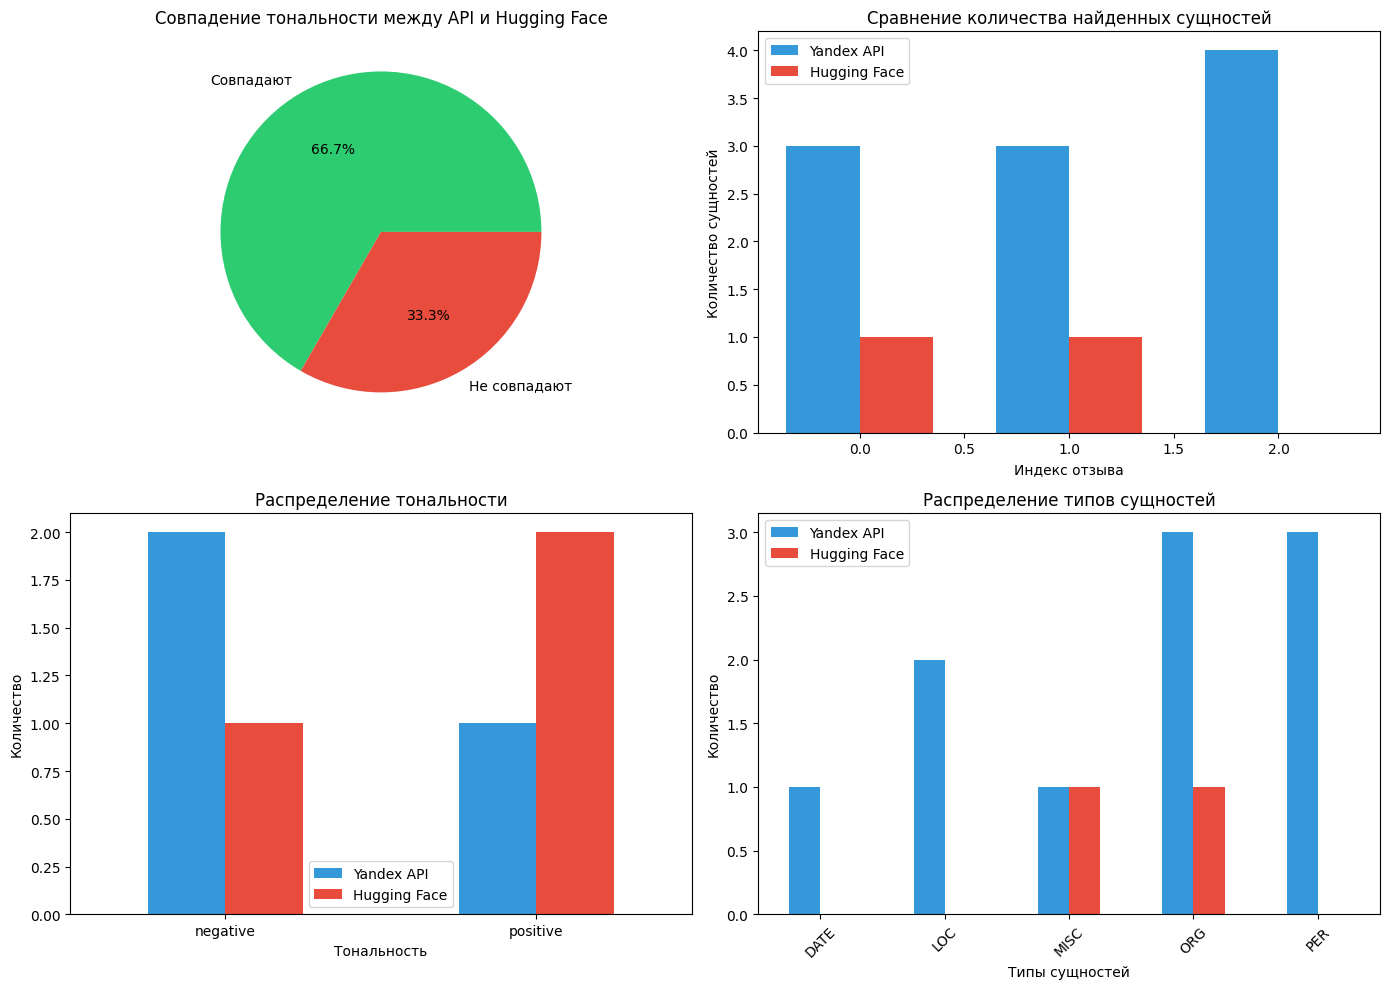

(   review_index                                        review_text  \
 0             0  отличный iphone 14 PRO!!!  купил в магазине  a...   
 1             1  УЖАСНОЕ обслуживание в сбербанке на красной пл...   
 2             2  Спасибо огромное сотрудникам МТС за то что 3 ч...   
 
   api_sentiment hf_sentiment  sentiment_match  api_entities_count  \
 0      positive     positive             True                   3   
 1      negative     negative             True                   3   
 2      negative     positive            False                   4   
 
    hf_entities_count                                       api_entities  \
 0                  1  [{'text': 'iphone 14 PRO', 'type': 'MISC'}, {'...   
 1                  1  [{'text': 'сбербанк', 'type': 'ORG'}, {'text':...   
 2                  0  [{'text': 'МТС', 'type': 'ORG'}, {'text': 'сот...   
 
                                          hf_entities  api_success  hf_success  
 0  [{'entity_group': 'MISC', 'score': 0.9322

In [61]:
# ==================== ФУНКЦИИ ДЛЯ СРАВНЕНИЯ РЕЗУЛЬТАТОВ ====================

def compare_results(api_results: List[Dict], hf_results: List[Dict]) -> pd.DataFrame:
    """
    Объединение и сравнение результатов API и Hugging Face

    Args:
        api_results: Результаты от Yandex LLM API
        hf_results: Результаты от Hugging Face моделей

    Returns:
        pd.DataFrame: Объединенная таблица сравнения
    """
    comparison_data = []

    for idx, (api_res, hf_res) in enumerate(zip(api_results, hf_results)):
        # Извлекаем тональность из API
        api_sentiment = None
        if 'sentiment' in api_res:
            if isinstance(api_res['sentiment'], dict):
                api_sentiment = api_res['sentiment'].get('sentiment', 'N/A')
            else:
                api_sentiment = api_res.get('sentiment', 'N/A')
        else:
            api_sentiment = 'N/A'

        # Извлекаем тональность из HF
        hf_sentiment = hf_res.get('sentiment', 'N/A')

        # Сравниваем совпадение тональности
        sentiment_match = (api_sentiment.lower() == hf_sentiment.lower()) if api_sentiment != 'N/A' and hf_sentiment != 'N/A' else None

        # Извлекаем сущности из API
        api_entities = []
        if 'ner' in api_res and 'entities' in api_res['ner']:
            api_entities = api_res['ner']['entities']
        elif 'entities' in api_res:
            api_entities = api_res['entities']

        # Извлекаем сущности из HF
        hf_entities = hf_res.get('entities', [])

        comparison_data.append({
            'review_index': idx,
            'review_text': api_res.get('_review_text', hf_res.get('text', ''))[:100],
            'api_sentiment': api_sentiment,
            'hf_sentiment': hf_sentiment,
            'sentiment_match': sentiment_match,
            'api_entities_count': len(api_entities),
            'hf_entities_count': len(hf_entities),
            'api_entities': api_entities,
            'hf_entities': hf_entities,
            'api_success': api_res.get('_metadata', {}).get('success', True) if '_metadata' in api_res else True,
            'hf_success': True  # HF всегда успешен если дошел до этой точки
        })

    return pd.DataFrame(comparison_data)

def analyze_comparison(comparison_df: pd.DataFrame) -> Dict:
    """
    Анализ сравнения результатов

    Returns:
        Dict: Статистика сравнения
    """
    # Фильтруем успешные результаты
    valid_df = comparison_df[comparison_df['api_success'] & comparison_df['hf_success']]

    stats = {
        'total_samples': len(comparison_df),
        'successful_both': len(valid_df),
        'api_errors': len(comparison_df[~comparison_df['api_success']]),
        'hf_errors': 0,  # HF у нас всегда успешен

        # Сравнение тональности
        'sentiment_agreement': valid_df['sentiment_match'].sum() if len(valid_df) > 0 else 0,
        'sentiment_agreement_rate': valid_df['sentiment_match'].mean() if len(valid_df) > 0 else 0,

        # Сравнение NER
        'avg_api_entities': valid_df['api_entities_count'].mean() if len(valid_df) > 0 else 0,
        'avg_hf_entities': valid_df['hf_entities_count'].mean() if len(valid_df) > 0 else 0,

        # Детали по тональности
        'sentiment_distribution_api': valid_df['api_sentiment'].value_counts().to_dict(),
        'sentiment_distribution_hf': valid_df['hf_sentiment'].value_counts().to_dict(),
    }

    return stats

def create_comparison_visualizations(comparison_df: pd.DataFrame, stats: Dict):
    """
    Создание визуализаций для сравнения
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # 1. Сравнение точности тональности
    ax1 = axes[0, 0]
    valid_df = comparison_df[comparison_df['api_success'] & comparison_df['hf_success']]
    if len(valid_df) > 0:
        sentiment_match_counts = valid_df['sentiment_match'].value_counts()
        if True in sentiment_match_counts.index:
            matches = sentiment_match_counts[True]
        else:
            matches = 0
        if False in sentiment_match_counts.index:
            mismatches = sentiment_match_counts[False]
        else:
            mismatches = 0

        ax1.pie([matches, mismatches],
                labels=['Совпадают', 'Не совпадают'],
                autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
        ax1.set_title('Совпадение тональности между API и Hugging Face')

    # 2. Сравнение количества найденных сущностей
    ax2 = axes[0, 1]
    x = range(len(valid_df))
    width = 0.35
    ax2.bar([i - width/2 for i in x], valid_df['api_entities_count'], width, label='Yandex API', color='#3498db')
    ax2.bar([i + width/2 for i in x], valid_df['hf_entities_count'], width, label='Hugging Face', color='#e74c3c')
    ax2.set_xlabel('Индекс отзыва')
    ax2.set_ylabel('Количество сущностей')
    ax2.set_title('Сравнение количества найденных сущностей')
    ax2.legend()

    # 3. Распределение тональности
    ax3 = axes[1, 0]
    sentiment_api = pd.Series(stats['sentiment_distribution_api'])
    sentiment_hf = pd.Series(stats['sentiment_distribution_hf'])

    df_sentiment = pd.DataFrame({
        'Yandex API': sentiment_api,
        'Hugging Face': sentiment_hf
    }).fillna(0)

    df_sentiment.plot(kind='bar', ax=ax3, color=['#3498db', '#e74c3c'])
    ax3.set_xlabel('Тональность')
    ax3.set_ylabel('Количество')
    ax3.set_title('Распределение тональности')
    ax3.legend()
    ax3.tick_params(axis='x', rotation=0)

    # 4. Сравнение сущностей по типам
    ax4 = axes[1, 1]

    # Собираем типы сущностей из обоих подходов
    api_entity_types = []
    hf_entity_types = []

    for _, row in valid_df.iterrows():
        for entity in row['api_entities']:
            api_entity_types.append(entity.get('type', 'UNKNOWN'))
        for entity in row['hf_entities']:
            hf_entity_types.append(entity.get('entity_group', 'UNKNOWN'))

    api_types_counts = pd.Series(api_entity_types).value_counts()
    hf_types_counts = pd.Series(hf_entity_types).value_counts()

    df_entity_types = pd.DataFrame({
        'Yandex API': api_types_counts,
        'Hugging Face': hf_types_counts
    }).fillna(0)

    if not df_entity_types.empty:
        df_entity_types.plot(kind='bar', ax=ax4, color=['#3498db', '#e74c3c'])
        ax4.set_xlabel('Типы сущностей')
        ax4.set_ylabel('Количество')
        ax4.set_title('Распределение типов сущностей')
        ax4.legend()
        ax4.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

def print_comparison_report(stats: Dict):
    """
    Вывод отчета о сравнении
    """
    print("\n" + "="*80)
    print("ОТЧЕТ О СРАВНЕНИИ YANDEX API vs HUGGING FACE")
    print("="*80)

    print(f"\n📊 ОБЩАЯ СТАТИСТИКА:")
    print(f"  Всего обработано: {stats['total_samples']}")
    print(f"  Успешно обоими: {stats['successful_both']}")
    print(f"  Ошибки API: {stats['api_errors']}")

    print(f"\n🎯 АНАЛИЗ ТОНАЛЬНОСТИ:")
    print(f"  Совпадение результатов: {stats['sentiment_agreement']}/{stats['successful_both']} ({stats['sentiment_agreement_rate']*100:.1f}%)")
    print(f"\n  Распределение API:")
    for sentiment, count in stats['sentiment_distribution_api'].items():
        print(f"    - {sentiment}: {count}")
    print(f"\n  Распределение Hugging Face:")
    for sentiment, count in stats['sentiment_distribution_hf'].items():
        print(f"    - {sentiment}: {count}")

    print(f"\n🔍 ИЗВЛЕЧЕНИЕ СУЩНОСТЕЙ:")
    print(f"  Среднее количество сущностей (API): {stats['avg_api_entities']:.2f}")
    print(f"  Среднее количество сущностей (HF): {stats['avg_hf_entities']:.2f}")
    print(f"  Разница: {abs(stats['avg_api_entities'] - stats['avg_hf_entities']):.2f}")

    print(f"\n💡 ВЫВОДЫ:")
    if stats['sentiment_agreement_rate'] > 0.7:
        print(f"  1. ✅ Высокое совпадение тональности ({stats['sentiment_agreement_rate']*100:.1f}%)")
    else:
        print(f"  1. ⚠️ Среднее совпадение тональности ({stats['sentiment_agreement_rate']*100:.1f}%)")

    if stats['avg_api_entities'] > stats['avg_hf_entities']:
        print(f"  2. 📌 Yandex API находит больше сущностей в среднем")
    else:
        print(f"  2. 📌 Hugging Face находит больше сущностей в среднем")

    print(f"\n📝 РЕКОМЕНДАЦИИ:")
    if stats['sentiment_agreement_rate'] > 0.8:
        print(f"  - Оба подхода дают схожие результаты по тональности")
    else:
        print(f"  - Рекомендуется использовать ансамбль подходов для повышения точности")

    if stats['avg_api_entities'] > stats['avg_hf_entities']:
        print(f"  - Yandex API лучше подходит для задач, требующих детального извлечения сущностей")
    else:
        print(f"  - Hugging Face эффективнее для быстрого анализа сущностей")

    print("\n" + "="*80)

# ==================== ОСНОВНОЙ БЛОК СРАВНЕНИЯ ====================

def run_comparison(df: pd.DataFrame, sample_size: int = 3):
    """
    Запуск сравнения результатов API и Hugging Face
    """
    # 1. Получаем результаты от API
    print("🔵 Получение результатов от Yandex API...")
    api_results = analyze_dataset_reviews(df, task="combined", sample_size=sample_size)

    # 2. Получаем результаты от Hugging Face
    print("\n🔴 Получение результатов от Hugging Face...")
    sample_reviews = df['cleaned_text'].head(sample_size).tolist()

    # Используем существующую функцию analyze_with_huggingface
    hf_results = analyze_with_huggingface(sample_reviews)

    # 3. Сравниваем результаты
    print("\n🟢 Сравнение результатов...")
    comparison_df = compare_results(api_results, hf_results)

    # 4. Анализируем сравнение
    stats = analyze_comparison(comparison_df)

    # 5. Выводим отчет
    print_comparison_report(stats)

    # 6. Создаем визуализации
    create_comparison_visualizations(comparison_df, stats)

    return comparison_df, stats

# ==================== ЗАПУСК ====================

# Запуск сравнения
run_comparison(df, sample_size=3)

## 📚 Часть 3: Подготовка данных для Fine-tuning LLM (20% оценки)

### Задание 3.1: Создание instruction-following датасета


In [ ]:
### Задание 2.3: Анализ сложных случаев

# Выберем специально сложные примеры для демонстрации преимуществ LLM
complex_cases = [
    "Спасибо огромное сотрудникам МТС за то что 3 часа держали меня в очереди! Просто восхитительно 👏",
    "iPhone 13 хороший телефон, но цена кусается. В целом доволен покупкой в re:Store",
    "Хотя Tesla Model Y и дорогая машина, и сервис в Рольф Премиум иногда подводит, но в целом я очень доволен покупкой",
    "норм телек LG купил в эльдорадо, продавец норм чел был, всё рассказал про функции"
]

print("Анализ сложных случаев:")
print("=" * 60)

# TODO: Сравните результаты HuggingFace и OpenAI на сложных случаях
# for i, text in enumerate(complex_cases):
#     print(f"\nПример {i+1}: {text}")
#     # hf_result = sentiment_pipeline(text)
#     # openai_result = analyze_with_openai([text])
#     # print(f"HuggingFace: {hf_result}")
#     # print(f"OpenAI: {openai_result}")





In [ ]:
### Задание 2.4: Количественное сравнение точности


# Создаем расширенный набор для тестирования с правильными ответами
test_cases_with_labels = [
    # Сарказм и ирония - должны быть NEGATIVE
    ("Спасибо огромное сотрудникам МТС за то что 3 часа держали меня в очереди! Просто восхитительно 👏", "NEGATIVE"),
    ("Какой замечательный сервис в Пятерочке - касса сломалась прямо передо мной, а персонал даже не извинился", "NEGATIVE"),

    # Смешанные эмоции - должны быть NEUTRAL или зависеть от преобладающего тона
    ("iPhone 13 хороший телефон, но цена кусается. В целом доволен покупкой в re:Store", "NEUTRAL"),
    ("Ресторан Белуга красивый и атмосфера приятная, но официант Максим был невнимателен", "NEUTRAL"),

    # Сложные структуры - требуют понимания контекста
    ("Хотя Tesla Model Y и дорогая машина, и сервис в Рольф Премиум иногда подводит, но в целом я очень доволен покупкой", "POSITIVE"),
    ("Не могу сказать что отель Ритц-Карлтон плохой, просто ожидал большего за такие деньги", "NEUTRAL"),

    # Неформальная речь и сленг
    ("норм телек LG купил в эльдорадо, продавец норм чел был, всё рассказал про функции", "POSITIVE"),
    ("Сходил в кинотеатр Октябрь посмотреть новый фильм Marvel - ну такое себе, но попкорн вкусный был", "NEUTRAL"),

    # Простые случаи для контроля
    ("отличный iphone 14 PRO!!! купил в магазине apple на тверской 😊. Камера супер", "POSITIVE"),
    ("УЖАСНОЕ обслуживание в сбербанке на красной площади.. менеджер иван петров вобще не помог(", "NEGATIVE")
]

# TODO: Рассчитайте точность для каждой модели
# hf_correct = 0
# openai_correct = 0
# total = len(test_cases_with_labels)



In [ ]:
### Задание 2.5: Визуализация сравнения моделей

import matplotlib.pyplot as plt
import numpy as np

# TODO: Создайте визуализацию сравнения точности моделей
# plt.figure(figsize=(12, 8))
# # Создайте графики сравнения

In [ ]:
def create_instruction_dataset(df: pd.DataFrame) -> List[Dict]:
    """
    Создание датасета в формате instruction-following для fine-tuning LLM
    """
    # TODO: Создайте структурированный датасет для fine-tuning LLM
    # Подумайте о структуре instruction-following датасета:
    # - Какие поля должны быть в каждом примере?
    # - Как сформулировать инструкции для модели?
    # - Какие типы задач включить (sentiment, NER, etc.)?
    # - Как структурировать ответы модели?
    #
    # Создайте несколько примеров для разных задач

    pass

# TODO: Протестируйте созданный датасет
# Создайте и проанализируйте instruction dataset
# Выведите примеры в читаемом формате
# Проанализируйте распределение типов задач



### Задание 3.2: Сериализация данных в формате для LLM платформ


In [ ]:
import json

# TODO: Реализуйте сохранение данных в форматах для fine-tuning
# Создайте функции для сохранения данных в форматах:
# 1. JSONL формат для OpenAI fine-tuning API
# 2. CSV формат для общего использования
#
# Изучите требования к форматам:
# - Какая структура нужна для OpenAI fine-tuning?
# - Как правильно структурировать messages?
# - Какие поля обязательны?
#
# Протестируйте сохранение и загрузку данных


